In [3]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [4]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [5]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [6]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [58]:
# MLP revisited
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
# squash the weights. Multiply by gain (5/3 for tanh) over sqrt(fan_in) where fan_in is the number of input elements
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/(n_embd * block_size)**0.5 
b1 = torch.randn(n_hidden,                        generator=g) * 0.01 # add a little bit of bias to the weights
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.01
b2 = torch.randn(vocab_size,                      generator=g) * 0 # don't want to add bias to random numbers at initialization

parameters = [C, W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

11897


tensor(0.0049) tensor(0.9874)
tensor(-0.0002) tensor(0.9842)


(array([2.29120546e-05, 0.00000000e+00, 1.14560273e-04, 1.14560273e-04,
        1.83296437e-04, 3.89504929e-04, 6.41537530e-04, 9.62306295e-04,
        2.03917286e-03, 2.81818272e-03, 3.87213723e-03, 6.11751859e-03,
        1.05166331e-02, 1.72756892e-02, 2.71049606e-02, 4.22956529e-02,
        6.28019418e-02, 9.10066810e-02, 1.26841134e-01, 1.76858150e-01,
        2.36452404e-01, 2.95748801e-01, 3.54518221e-01, 4.01877438e-01,
        4.28638718e-01, 4.35008269e-01, 4.05749576e-01, 3.55274319e-01,
        2.91326775e-01, 2.35673394e-01, 1.74429472e-01, 1.28055473e-01,
        8.95173975e-02, 6.22520524e-02, 4.19290600e-02, 2.71966089e-02,
        1.79630508e-02, 1.03333366e-02, 7.12564899e-03, 4.88026764e-03,
        2.54323806e-03, 1.46637150e-03, 9.16482185e-04, 6.64449584e-04,
        3.66592874e-04, 2.29120546e-04, 9.16482185e-05, 6.87361639e-05,
        4.58241093e-05, 9.16482185e-05]),
 array([-5.45529222e+00, -5.23706649e+00, -5.01884075e+00, -4.80061502e+00,
        -4.5823892

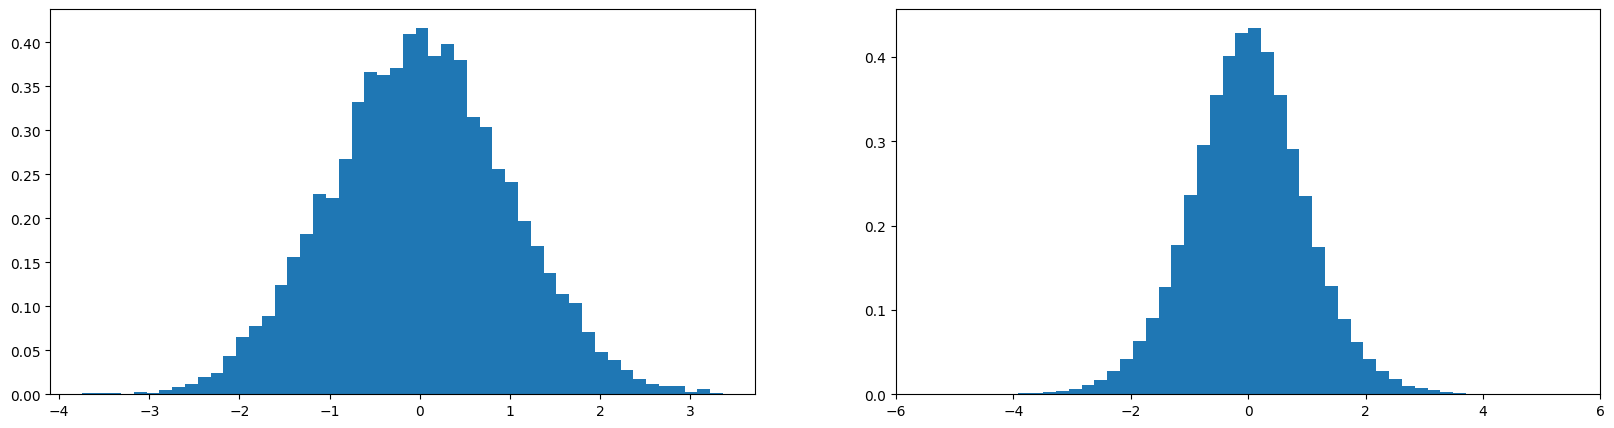

In [59]:
# analysis: matrix multiplication of two normally distributed matrices causes the new matrix to have a wider standard deviation
# however we want a roughly unit gaussian throughout the neural net
x = torch.randn(1000, 10)
w = torch.randn(10, 200) / 10**0.5 # normalize y by dividing w by sqrt(fan_in) where fan_in is the number of input elements
y = x @ w
print(x.mean(), x.std())
print(y.mean(), y.std())
plt.figure(figsize=(20, 5))
plt.subplot(121)
plt.hist(x.view(-1).tolist(), 50, density=True)
plt.subplot(122)
plt.hist(y.view(-1).tolist(), 50, density=True)

In [52]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass
  emb = C[Xb] # embed the characters into vectors
  embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
  # Linear layer
  hpreact = embcat @ W1 + b1 # hidden layer pre-activation
  h = torch.tanh(hpreact) # hidden layer
  logits = h @ W2 + b2 # output layer
  loss = F.cross_entropy(logits, Yb) # loss function
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())
  #break

      0/ 200000: 3.3135
  10000/ 200000: 2.1648
  20000/ 200000: 2.3061
  30000/ 200000: 2.4541
  40000/ 200000: 1.9787
  50000/ 200000: 2.2930
  60000/ 200000: 2.4232
  70000/ 200000: 2.0680
  80000/ 200000: 2.3095
  90000/ 200000: 2.1207
 100000/ 200000: 1.8269
 110000/ 200000: 2.2045
 120000/ 200000: 1.9797
 130000/ 200000: 2.3946
 140000/ 200000: 2.1000
 150000/ 200000: 2.1948
 160000/ 200000: 1.8619
 170000/ 200000: 1.7809
 180000/ 200000: 1.9673
 190000/ 200000: 1.8295


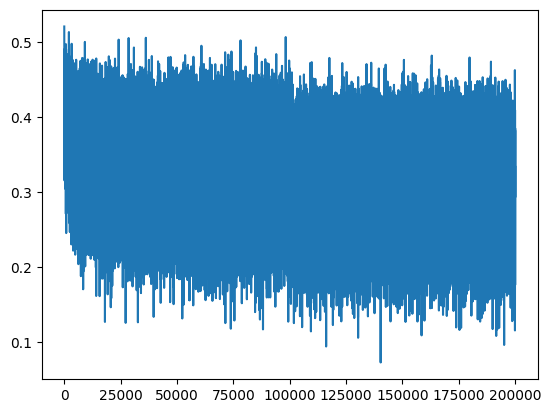

In [53]:
plt.plot(lossi)

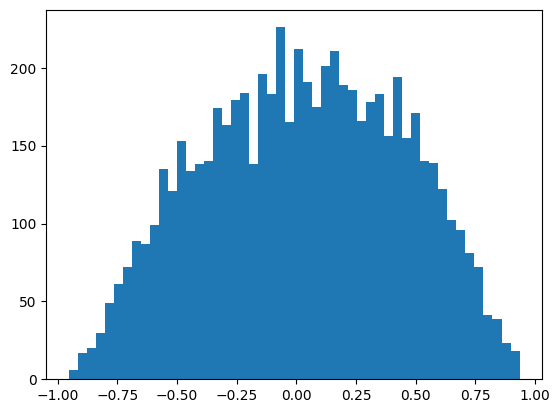

In [47]:
# post activation (after going through tanh function) => Shows our tanh is very active meaning most values go to the ends of the function
plt.hist(h.view(-1).tolist(), 50); # converting all the outputs of the hidden layer to a list to then visualize where the data lies

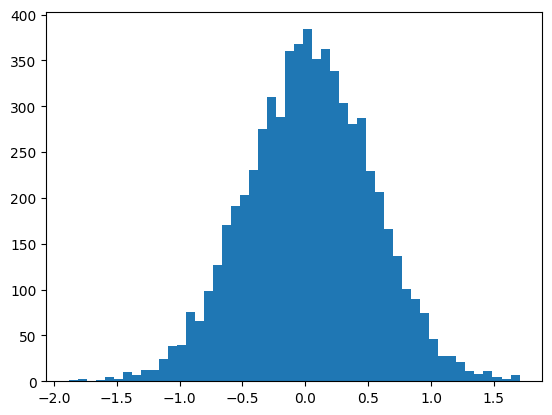

In [48]:
# pre activation (before passing through tanh function) => very broad 
# this is not good, 
plt.hist(hpreact.view(-1).tolist(), 50);

In [49]:
# what the two previous graphs show is that backpropogation is not very effective since our values end up on the tail ends of tanh
# this means we require more changes to our parameters to efficiently modify our loss since small changes will not move us a lot on the tail ends of tanh
# gradient is basically zero at these ends
# gradients flowing through the network get destroyed at these ends

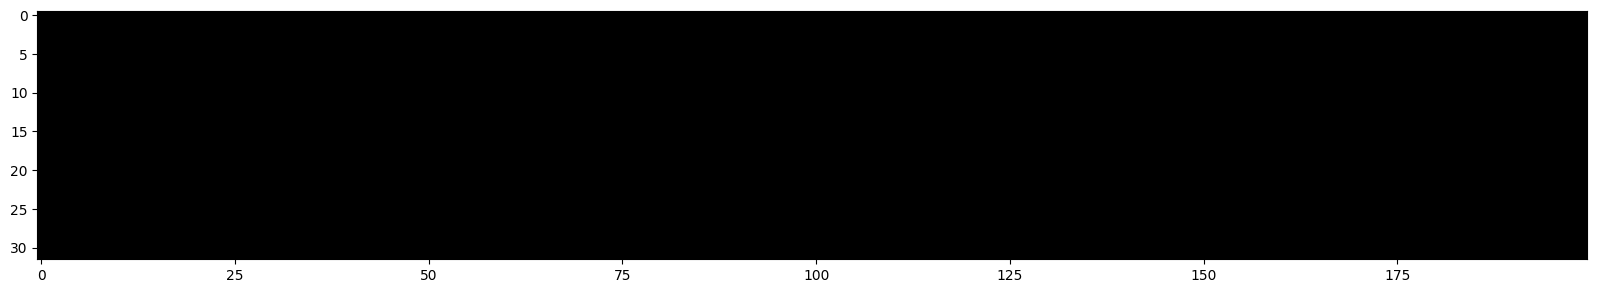

In [50]:
plt.figure(figsize=(20,10))
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest') # 32 examples, 200 hidden neurons
# each white part shows a part of a neuron where the backward gradient gets destroyed
# a whole column of white means there is a dead neuron, meaning no example will ever activate the function

In [9]:
# Our intial loss is high
-torch.tensor(1/27.0).log()

tensor(3.2958)

In [11]:
# 4-dimensional example of the issue
# logits = torch.tensor([0.0, 0.0, 0.0, 0.0])
logits = torch.randn(4)
probs = torch.softmax(logits, dim=0)
loss = -probs[2].log()
logits, probs, loss

(tensor([ 0.4428,  1.2353, -0.4949,  0.5353]),
 tensor([0.2129, 0.4702, 0.0834, 0.2335]),
 tensor(2.4847))

In [54]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  h = torch.tanh(embcat @ W1 + b1) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.0355966091156006
val 2.1026785373687744


In [55]:
loss log
original:
train 2.1245384216308594 val 2.168196439743042

fix softmax confidently wrong:
train 2.07 val 2.13

fix tanh layer too saturated at init:
train 2.0355966091156006 val 2.1026785373687744

use semi-principled "kaiming init" instead of hacky init:
train 2.0376641750335693 val 2.106989622116089

add batch norm layer
train 2.0668270587921143 val 2.104844808578491

SyntaxError: invalid syntax (1792380959.py, line 1)